# IPL Match Analysis (2008 - 2025)
## Notebook 2 - EDA: Match Level Insights

** Business Questions**
1. Which team has won the most matches in IPL history?
2. Does winnning the toss help win the match?
3. Is batting first or chasing more successful?
4. Which venues produce the most wins for home teams?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

#Loading clean data
df = pd.read_csv('../data/IPL_clean.csv')

print(f"Clean data loaded")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

C:\Users\bhava\AppData\Local\Temp\ipykernel_23168\2447444068.py:9: DtypeWarning: Columns (28,29,30,31,43,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/IPL_clean.csv')


Clean data loaded
Rows: 273,503
Columns: 64


In [2]:
# question 1

#count wins per team
team_wins = df.groupby('match_won_by')['match_id'].nunique().reset_index()
team_wins.columns = ['team','wins']
team_wins = team_wins.sort_values('wins', ascending = False)

print('Team Win Counts:')
print(team_wins)

Team Win Counts:
                           team  wins
7                Mumbai Indians   151
0           Chennai Super Kings   142
5         Kolkata Knight Riders   135
11  Royal Challengers Bengaluru   132
12          Sunrisers Hyderabad   122
8                  Punjab Kings   119
1                Delhi Capitals   118
9              Rajasthan Royals   114
3                Gujarat Titans    37
6          Lucknow Super Giants    30
10       Rising Pune Supergiant    27
2                 Gujarat Lions    13
4          Kochi Tuskers Kerala     6


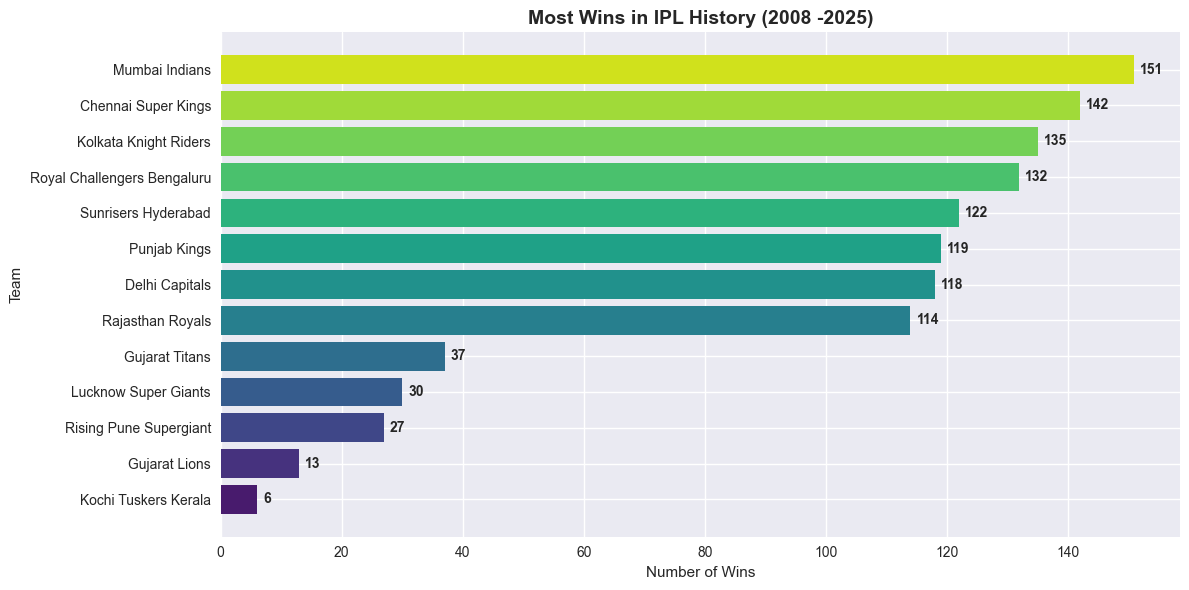

Chart saved


In [7]:
#plot team wins
plt.figure(figsize = (12,6))

bars = plt.barh(team_wins['team'][::-1],
                team_wins['wins'][::-1],
                color = sns.color_palette('viridis', len(team_wins)))

plt.title('Most Wins in IPL History (2008 -2025)',
          fontsize = 14, fontweight ='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

#add value labels on bars
for bar , val in zip(bars,team_wins['wins'][::-1]):
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             str(val), va ='center', fontweight = 'bold')
    
plt.tight_layout()
plt.savefig('../data/team_wins.png' , dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

### Finding 1: Team Wins Analysis
- **Mumbai Indians** are the most successful team 
  with 151 wins across 18 seasons
- **CSK and KKR** follow closely at 142 and 135 wins
- Bottom 5 teams have fewer wins due to shorter 
  existence or being defunct franchises
- Top 4 teams account for ~40% of all IPL wins

In [18]:
# question 2

#get one row per match
matches = df.drop_duplicates(subset = 'match_id').copy()

print(f"Total unique matches: {len(matches):,}")

#did toss winner win the match?

matches['toss_won_match'] = matches['toss_winner'] == matches['match_won_by']

toss_win_pct = matches['toss_won_match'].mean() *100

print(f"\nToss winner won the match : {toss_win_pct:.1f}%")
print(f"Toss winner lost the match : {100-toss_win_pct:.1f}%")

Total unique matches: 1,146

Toss winner won the match : 51.6%
Toss winner lost the match : 48.4%


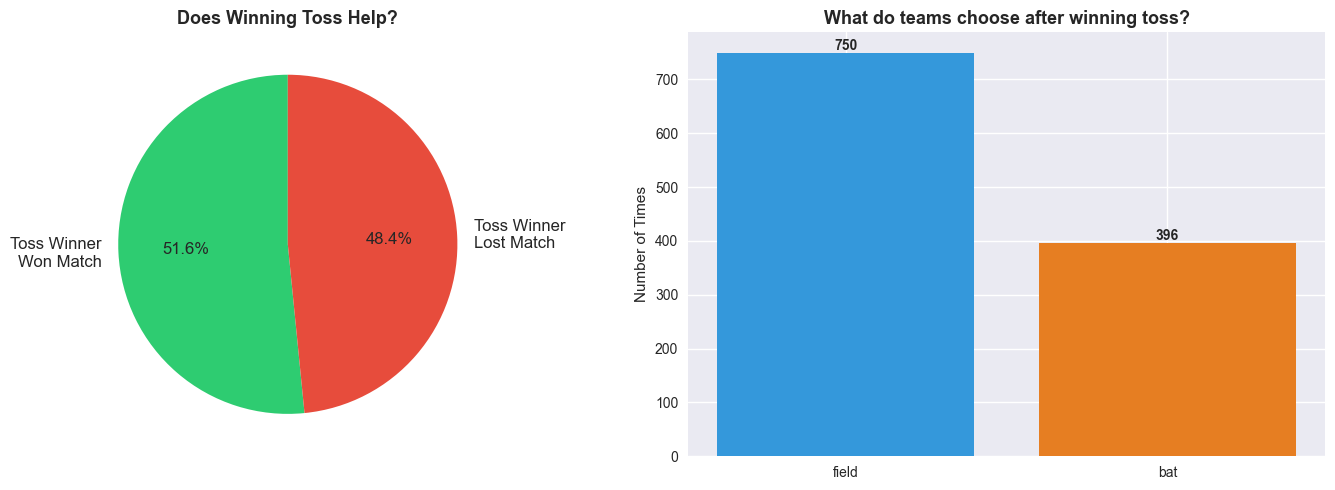

chart saved


In [22]:
fig, axes = plt.subplots(1,2, figsize =(14,5))

# toss win and loss pie chart
labels = ['Toss Winner\nWon Match', 'Toss Winner\nLost Match']
sizes = [toss_win_pct,100-toss_win_pct]
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(sizes,labels=labels,colors=colors,
            autopct = '%1.1f%%' , startangle = 90,
            textprops={'fontsize' : 12})
axes[0].set_title('Does Winning Toss Help?',
                  fontsize = 13, fontweight = 'bold')

#plot 2 - Toss Decision (bat vs field)
toss_decision = matches['toss_decision'].value_counts()
axes[1].bar(toss_decision.index,
            toss_decision.values,color = ['#3498db', '#e67e22'])
axes[1].set_title('What do teams choose after winning toss?',
                  fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Number of Times')

for i, val in enumerate(toss_decision.values):
    axes[1].text(i, val + 5, str(val),
                 ha = 'center', fontweight = 'bold')
    
plt.tight_layout()
plt.savefig('../data/toss_analysis.png' , dpi = 150, bbox_inches = 'tight')
plt.show()
print("chart saved")

### Finding 2: Toss Analysis
- Toss winner wins only **51.6%** of matches
- Toss is essentially a coin flip — minimal advantage
- However teams strongly prefer to **field first** (65%)
  after winning toss
- This raises Question 3: does fielding first 
  actually lead to more wins?

In [23]:
# Who wins more — team batting first or chasing?
# innings 1 = batting first, innings 2 = chasing

# Get first innings batting team per match
first_innings = df[df['innings'] == 1].drop_duplicates(
    subset='match_id')[['match_id', 'batting_team']].copy()
first_innings.columns = ['match_id', 'batting_first']

# Get match winner
match_winners = matches[['match_id', 'match_won_by']].copy()

# Merge
match_result = first_innings.merge(match_winners, on='match_id')

# Did batting first team win?
match_result['batting_first_won'] = (
    match_result['batting_first'] == match_result['match_won_by']
)

bat_first_win_pct = match_result['batting_first_won'].mean() * 100
chase_win_pct = 100 - bat_first_win_pct

print(f"Batting first win %: {bat_first_win_pct:.1f}%")
print(f"Chasing win %: {chase_win_pct:.1f}%")

Batting first win %: 45.8%
Chasing win %: 54.2%


### Finding 3: Batting First vs Chasing
- Chasing teams win **54.2%** of matches
- Batting first teams win only **45.8%**
- This validates why 65% of toss winners choose to field
- Chasing advantage is real and statistically significant

C:\Users\bhava\AppData\Local\Temp\ipykernel_23168\3339680239.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  toss_analysis = matches.groupby('toss_decision').apply(


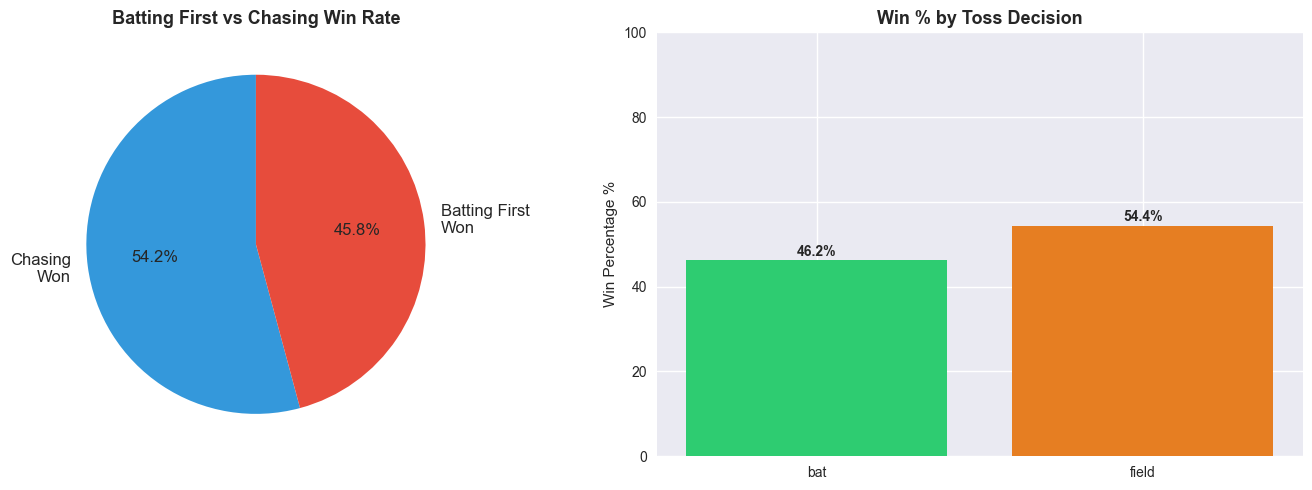

Chart saved ✅


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Bat first vs Chase
labels = ['Chasing\nWon', 'Batting First\nWon']
sizes = [chase_win_pct, bat_first_win_pct]
colors = ['#3498db', '#e74c3c']

axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Batting First vs Chasing Win Rate',
                   fontsize=13, fontweight='bold')

# Plot 2 — Win % by toss decision
toss_analysis = matches.groupby('toss_decision').apply(
    lambda x: (x['toss_winner'] == x['match_won_by']).mean() * 100
).reset_index()
toss_analysis.columns = ['toss_decision', 'win_pct']

axes[1].bar(toss_analysis['toss_decision'],
            toss_analysis['win_pct'],
            color=['#2ecc71', '#e67e22'])
axes[1].set_title('Win % by Toss Decision',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Win Percentage %')
axes[1].set_ylim(0, 100)

for i, val in enumerate(toss_analysis['win_pct']):
    axes[1].text(i, val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/batting_vs_chasing.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")